<a href="https://colab.research.google.com/github/MinhQuann205/TH-DeepLearning/blob/main/BaiThucHanhBuoi4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras

from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential

# for keras import Input
# data visualization packages
import matplotlib.pyplot as pltv

In [2]:
mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test  = '/content/sample_data/mnist_test.csv'

df_train = pd.read_csv(mnist_train)
df_test  = pd.read_csv(mnist_test)

print(df_train.shape)

X_train = df_train.iloc[:,1:]
y_train = df_train.iloc[:,0]

X_test = df_test.iloc[:,1:]
y_test = df_test.iloc[:,0]

print(X_train.shape,
      y_train.shape,
      X_test.shape,
      y_test.shape)

(19999, 785)
(19999, 784) (19999,) (9999, 784) (9999,)


In [3]:
num_classes = 10
input_shape = (28, 28, 1)

X_train = X_train.astype("float32") / 255
X_test  = X_test.astype("float32") / 255

X_train = X_train.to_numpy()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)

X_test = X_test.to_numpy()
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

print(X_test.shape)

print("Number of classes:", len(np.unique(y_train)))
print("Classes:", np.unique(y_train))

print(y_train[:5])

(9999, 28, 28, 1)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
0    5
1    7
2    9
3    5
4    2
Name: 6, dtype: int64


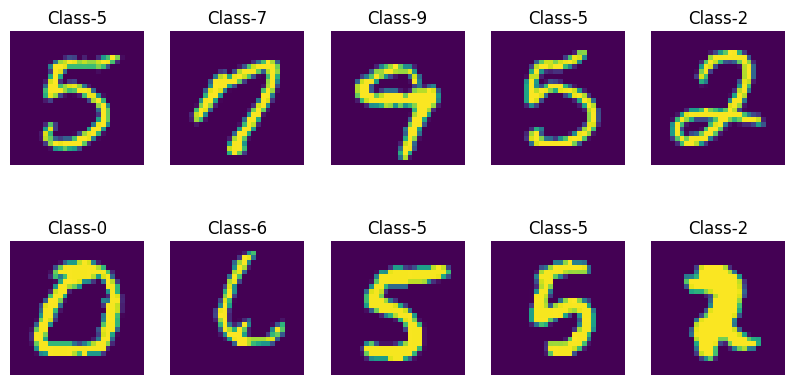

In [4]:
fig, axes = pltv.subplots(2,5, figsize=(10,5))

for i in range(10):
    pltv.subplot(2,5,i+1)
    pltv.imshow(X_train[i].reshape(28,28))
    pltv.title("Class-" + str(y_train[i]))
    pltv.axis('off')

pltv.show()

In [5]:
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test  = keras.utils.to_categorical(y_test, num_classes)

In [6]:
model = Sequential()

model.add(Conv2D(
    32,
    kernel_size=(3,3),
    activation='relu'
))

model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(
    64,
    kernel_size=(3,3),
    activation='relu'
))

model.add(MaxPool2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(
    units=10,
    activation='softmax'
))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
y_train = df_train.iloc[:, 0]
y_train = keras.utils.to_categorical(y_train, num_classes)

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_fit = model.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=15,
    validation_split=0.2
)

Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.8233 - loss: 0.6382 - val_accuracy: 0.9365 - val_loss: 0.2120
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.9548 - loss: 0.1530 - val_accuracy: 0.9617 - val_loss: 0.1265
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.9699 - loss: 0.1031 - val_accuracy: 0.9680 - val_loss: 0.1004
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.9744 - loss: 0.0829 - val_accuracy: 0.9745 - val_loss: 0.0864
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.9792 - loss: 0.0669 - val_accuracy: 0.9730 - val_loss: 0.0811
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.9827 - loss: 0.0574 - val_accuracy: 0.9758 - val_loss: 0.0763
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.9852 - loss: 0.0479 - val_accuracy: 0.9755 - val_loss: 0.0716
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - accuracy: 0.9873 - loss: 0.0408 - val_a

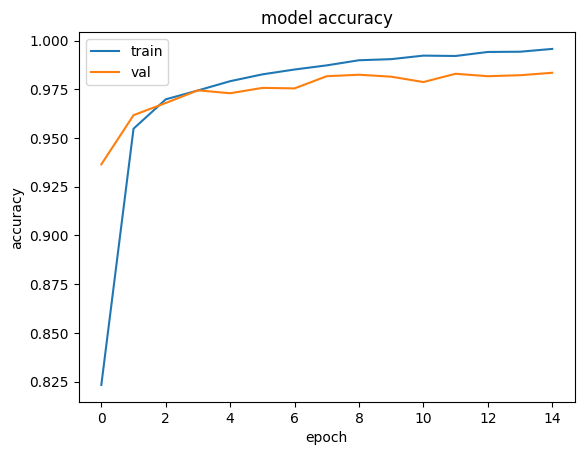

In [9]:
pltv.plot(model_fit.history['accuracy'])
pltv.plot(model_fit.history['val_accuracy'])

pltv.title('model accuracy')
pltv.ylabel('accuracy')
pltv.xlabel('epoch')

pltv.legend(['train', 'val'], loc='upper left')
pltv.show()

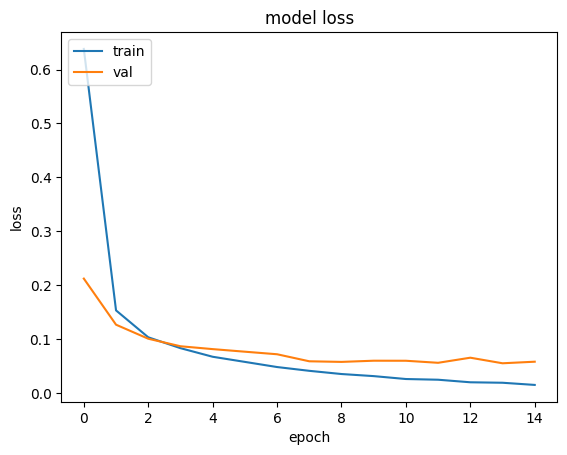

In [11]:
pltv.plot(model_fit.history['loss'])
pltv.plot(model_fit.history['val_loss'])

pltv.title('model loss')
pltv.ylabel('loss')
pltv.xlabel('epoch')

pltv.legend(['train', 'val'], loc='upper left')
pltv.show()

In [12]:
score = model.evaluate(
    X_test,
    y_test,
    verbose=2
)

print("Test loss:", score[0])
print("Test accuracy:", score[1])

313/313 - 2s - 7ms/step - accuracy: 0.9838 - loss: 0.0585
Test loss: 0.05848955735564232
Test accuracy: 0.9837983846664429


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
[[4.58760223e-06 6.95706040e-05 9.99922991e-01 1.37281245e-11
  6.71722770e-19 1.25492024e-13 2.84881935e-06 1.28623488e-16
  1.50329305e-09 1.50429787e-19]]
2 2


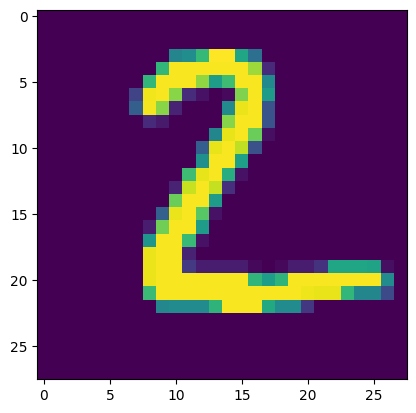

In [14]:
predict = model.predict(X_test[:1])

print(predict)

print(
    np.argmax(predict),
    np.argmax(y_test[0])
)

pltv.imshow(X_test[:1].reshape(28,28))
pltv.show()

In [17]:
model.save_weights('cnn.weights.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
[[0.09797052 0.09651044 0.09131615 0.08430518 0.10968937 0.10684235
  0.10194375 0.10742002 0.10290682 0.10109537]]
4 1


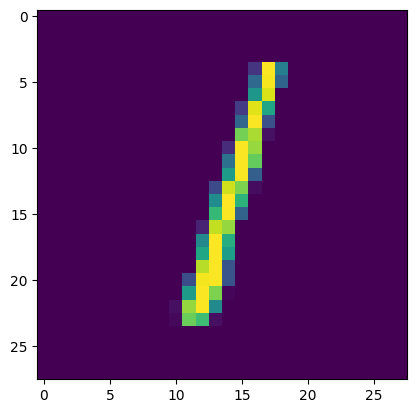

In [19]:
model = Sequential()

model.add(tf.keras.Input(shape=input_shape))

model.add(
    Conv2D(
        32,
        kernel_size=(3,3),
        activation='relu'
    )
)

model.add(
    MaxPool2D(
        pool_size=(2,2)
    )
)

model.add(
    Conv2D(
        64,
        kernel_size=(3,3),
        activation='relu'
    )
)

model.add(
    MaxPool2D(
        pool_size=(2,2)
    )
)

model.add(Flatten())

model.add(
    Dense(
        units=10,
        activation='softmax'
    )
)

model.load_weights("cnn.weights.h5")

predict = model.predict(X_test[1:2])

print(predict)

print(
    np.argmax(predict),
    np.argmax(y_test[1])
)

pltv.imshow(X_test[1:2].reshape(28,28))
pltv.show()